**[Text 01]**

# Uncertainty-Aware MPC: Planning Through What the Model Does Not Know

*Companion notebook — W33 trend tutorial, [Probabilistic World Models](https://artifocial.com/blog/probabilistic-world-models-2026-aug-15).*

A learned world model is only a model *of the data it saw*. Drive a planner into a region the training
distribution never covered and the model does not fall silent — it answers anyway, fluently and wrongly.
A zero-mean [Gaussian process](https://github.com/artifocial/tutorials/blob/main/2026-W28/00_gp_attention_from_scratch.ipynb)
far from its data reverts to its prior mean of **zero**, which a point-estimate planner reads as the
cheerful sentence *"nothing happens here."* That is the most dangerous thing a dynamics model can say.

This notebook builds the smallest honest experiment that separates the two failure modes. A 2-D vehicle
must cross a workspace to a goal. An unmodelled disturbance — a convergent downdraft — sits squarely on
the straight-line path, and the prior policy that generated the training data always went *around* it,
so the GP has a disc-shaped blind spot exactly where the hazard lives. We then run **the same MPC
planner, the same budget, the same cost function** twice. The only difference is whether the predicted
state is a point or a Gaussian. The uncertainty-aware agent's cost is [PILCO](https://arxiv.org/abs/1502.02860)'s
saturating cost *in expectation under the propagated posterior*; the point-estimate agent gets the identical
functional with $\Sigma = 0$, at which point it collapses **exactly** to the deterministic cost. No
hand-added uncertainty bonus, no extra penalty term — that is what makes the ablation clean rather than rigged.

Everything is NumPy on CPU and runs in a few minutes. It is a toy at toy scale: it replicates no published
result, and propagating a posterior is not a safety guarantee. What it does show is narrower and worth
seeing directly — that the information which would have saved the run was *already inside the model*, and
the point-estimate planner threw it away.

In [1]:
# [Code 01] Environment setup — uv-first, pip fallback (works everywhere)
import importlib, subprocess, sys, shutil

def ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p) is None]
    if not missing:
        return
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure(["numpy", "matplotlib"])

import time
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
T_START = time.time()
print("NumPy", np.__version__)

NumPy 2.5.2


**[Text 02]**

## The Task and the Thing Nobody Told the Model About

The state is a position $s=(x,y)$. The agent starts at $(0,0)$, wants to reach $(6,0)$, and each step
applies an action clipped to $\lVert a\rVert \le 0.5$. The true dynamics are

$$s_{t+1} = s_t + a_t + f(s_t)$$

where $f$ is an unknown residual drift the agent never modelled. We use a **convergent downdraft** centred
on $(3,0)$ — a column of sinking air with a weak horizontal inflow feeding it:

$$
e(s) = A\,\exp\!\Big(\!-\big(u^2 + (y/\sigma_y)^2\big)\Big),\quad u=\frac{x-3}{w_x},\qquad
f(s) = \big(-k_x\,u\,e(s),\; -e(s)\big)
$$

with $\sigma_y = \sigma_{\text{up}}$ above the core and $\sigma_{\text{down}}$ below it. The downdraft
weakens quickly with altitude and persists far below, and the inflow $-k_x u$ points back toward $x=3$ from
either side. At the core, $\lVert f\rVert$ is several times the agent's maximum action: once inside, the
agent cannot fight its way out.

The horizontal term matters, and we did not start with it. Our first environment used the textbook
"vertical shove only," $f = (0, -A e)$ — and it produced no interesting result at all, for a reason worth
stating up front (callout below).

In [2]:
# [Code 02] The environment: constants, the true drift f(s), and the data-gap disc
CFG = dict(
    X_LO=-1.0, X_HI=7.2, Y_LO=-4.0, Y_HI=3.2,        # workspace box (states are clipped to it)
    A=3.0, WX=1.0, SU=0.8, SD=6.0, KX=0.7,           # downdraft: amplitude, widths, inflow gain
    GAP_CX=3.0, GAP_CY=0.0, GAP_R=2.2,               # the disc the prior policy never entered
    GRID=0.45, LS=0.8, SN=0.02,                      # training grid pitch, GP lengthscale, obs noise
    AMAX=0.5, T=20,                                  # action budget per step, episode length
    START=(0.0, 0.0), GOAL=(6.0, 0.0),
)
GOAL = np.array(CFG["GOAL"])
GAPC = np.array([CFG["GAP_CX"], CFG["GAP_CY"]])
LO = np.array([CFG["X_LO"], CFG["Y_LO"]]); HI = np.array([CFG["X_HI"], CFG["Y_HI"]])

def drift(S, c=CFG):
    # True unknown residual f(s).  S: (...,2) -> (...,2)
    S = np.atleast_2d(np.asarray(S, float))
    x, y = S[..., 0], S[..., 1]
    u = (x - c["GAP_CX"]) / c["WX"]
    sy = np.where(y > 0, c["SU"], c["SD"])           # weak above the core, persistent below
    e = c["A"] * np.exp(-(u ** 2 + (y / sy) ** 2))
    return np.stack([-c["KX"] * u * e, -e], axis=-1)

def in_gap(S, c=CFG):
    S = np.atleast_2d(np.asarray(S, float))
    return ((S[..., 0] - c["GAP_CX"]) ** 2 + (S[..., 1] - c["GAP_CY"]) ** 2) < c["GAP_R"] ** 2

core = np.linalg.norm(drift(GAPC)[0])
print(f"|f| at the downdraft core   = {core:.2f}")
print(f"max action ||a||           = {CFG['AMAX']:.2f}   ->  disturbance / actuation = {core/CFG['AMAX']:.1f}x")
assert core > 3 * CFG["AMAX"], "the hazard must be un-fightable for the experiment to mean anything"

# Is it actually a trap?  Push +x at full throttle from the floor of the core and see if we escape.
s = np.array([3.5, CFG["Y_LO"]]); xs = []
for _ in range(25):
    s = np.clip(s + np.array([CFG["AMAX"], 0.0]) + drift(s)[0], LO, HI); xs.append(s[0])
print(f"full-throttle escape along the floor: x goes {xs[0]:.2f} -> {xs[-1]:.2f} in 25 steps")
print("trapped" if xs[-1] - xs[0] < 0.2 else "escapes")

|f| at the downdraft core   = 3.00
max action ||a||           = 0.50   ->  disturbance / actuation = 6.0x
full-throttle escape along the floor: x goes 3.48 -> 3.46 in 25 steps
trapped


**[Callout 01]**

### Engineering callout: a purely perpendicular disturbance is not a hazard

Our first environment was the obvious one — a downward Gaussian shove, $f(s) = (0, -A\,e(s))$, with the
goal displaced purely in $x$. We tuned the amplitude up to $A = 4$, eight times the agent's action limit,
and the naive agent *still won*.

**What went wrong:** with $f_x \equiv 0$, nothing ever slows the agent's progress toward the goal. Being
shoved down by $h$ costs roughly $\sqrt{\Delta x^2 + h^2} - \Delta x$ of extra path — which is geometrically
the *same* price as deliberately detouring *over* a hazard of height $h$. An open-loop greedy agent driven
straight through a shove with $A=4$ was swept to $y \approx -4.3$ and still reached the goal on step 20.
The "catastrophe" and the "prudent detour" cost the same, so there was nothing to measure.

**The fix:** add a weak convergent inflow, $f_x = -k_x u\, e(s)$, so the disturbance is an *attractor*
rather than a push. Now the hazard removes the agent's ability to make progress, and the trap is real:
the full-throttle escape test in `[Code 02]` shows the agent pinned.

**Lesson:** a hazard only produces a measurable failure if it attacks the quantity the objective rewards.
Before blaming a planner for not avoiding your obstacle, check that entering the obstacle is actually
worse than the detour — in many hand-built 2-D benchmarks it quietly is not, and you end up tuning a
planner against a distinction the environment never made.

**[Text 03]**

## The Transition Model: an Exact GP, With a Hole In It

We reuse the [W28 GP](https://artifocial.com/notebooks/2026-W28/00_gp_attention_from_scratch) —
RBF kernel, exact posterior — as the transition model. Two independent GPs, one per output dimension,
share inputs and lengthscale:

$$
k(s,s') = \sigma_f^2\exp\!\Big(-\tfrac{\lVert s-s'\rVert^2}{2\ell^2}\Big),\qquad
\mu_d(s_*) = k_*^\top K^{-1}y_d,\qquad
\sigma_d^2(s_*) = \sigma_{f,d}^2 - k_*^\top K^{-1} k_*
$$

The training set is the crux. It is a lattice over the whole workspace **minus a disc of radius 2.2
around $(3,0)$** — the prior policy that collected this data always steered around the storm cell, so
there is not one observation from inside it. Everywhere else the GP sees the drift and nails it. Inside
the disc it has nothing, so the posterior mean decays toward the zero prior while the posterior standard
deviation rises to the prior signal scale.

In [3]:
# [Code 03] An exact GP, one per output dim, sharing the correlation matrix
def sqdist(A_, B_):
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a.b  — one BLAS matmul instead of an (M,N,2) broadcast
    return np.maximum((A_ ** 2).sum(1)[:, None] + (B_ ** 2).sum(1)[None, :] - 2.0 * (A_ @ B_.T), 0.0)

class GPModel:
    # Exact GP regression, one output dim per GP, shared inputs and lengthscale
    def __init__(self, X, Y, ls, sn, sf):
        self.X, self.ls, self.sn, self.sf = X, ls, sn, np.asarray(sf, float)
        n = len(X)
        R = np.exp(-sqdist(X, X) / (2 * ls ** 2))            # correlation, shared by both dims
        self.L, self.Kinv, self.alpha = [], [], []
        for d in range(Y.shape[1]):
            K = self.sf[d] ** 2 * R + (sn ** 2) * np.eye(n) + 1e-8 * np.eye(n)   # jitter
            L = np.linalg.cholesky(K)                        # fails loudly if K is not PD
            Ki = np.linalg.inv(K)
            self.L.append(L); self.Kinv.append(Ki); self.alpha.append(Ki @ Y[:, d])
        self.Kinv = np.array(self.Kinv); self.alpha = np.array(self.alpha)

    def predict(self, Xs):
        # Batched posterior mean and marginal variance. Xs: (M,2) -> (M,2), (M,2)
        R = np.exp(-sqdist(Xs, self.X) / (2 * self.ls ** 2))
        mu = np.empty((len(Xs), 2)); var = np.empty((len(Xs), 2))
        for d in range(2):
            Ks = self.sf[d] ** 2 * R
            mu[:, d] = Ks @ self.alpha[d]
            var[:, d] = self.sf[d] ** 2 - ((Ks @ self.Kinv[d]) * Ks).sum(1)
        return mu, np.clip(var, 1e-12, None)                 # clip: floating point can dip below 0

In [4]:
# [Code 04] Collect training data everywhere EXCEPT the gap disc, fit the GPs, inspect the blind spot
def make_data(c=CFG, seed=0):
    r = np.random.default_rng(seed)
    gx = np.arange(c["X_LO"], c["X_HI"] + 1e-9, c["GRID"])
    gy = np.arange(c["Y_LO"], c["Y_HI"] + 1e-9, c["GRID"])
    G = np.stack(np.meshgrid(gx, gy, indexing="ij"), -1).reshape(-1, 2)
    G = G + r.normal(0, 0.06, size=G.shape)                  # jitter off the lattice
    X = G[~in_gap(G, c)]
    return X, drift(X, c) + r.normal(0, c["SN"], size=X.shape)

Xtr, Ytr = make_data()
SF = np.abs(Ytr).max(0)          # prior signal std = largest residual magnitude ever observed
gp = GPModel(Xtr, Ytr, CFG["LS"], CFG["SN"], SF)

print(f"{len(Xtr)} training states, none inside the disc r={CFG['GAP_R']} about "
      f"({GAPC[0]:.0f}, {GAPC[1]:.0f})")
print(f"prior signal std  sigma_f = ({SF[0]:.2f}, {SF[1]:.2f})   [x-dim, y-dim]")
print()
probe = np.array([[3.0, 0.0], [2.0, 0.0], [3.0, 2.5], [3.0, -3.0], [1.0, 0.0]])
mu_p, var_p = gp.predict(probe); sd_p = np.sqrt(var_p); tru_p = drift(probe)
print(f"{'state':>12} {'GP mean':>18} {'GP std':>16} {'TRUE f(s)':>18}  in gap?")
for s_, m_, d_, t_ in zip(probe, mu_p, sd_p, tru_p):
    print(f"{f'({s_[0]:.1f},{s_[1]:5.1f})':>12} ({m_[0]:7.2f},{m_[1]:7.2f}) ({d_[0]:6.2f},{d_[1]:6.2f})"
          f" ({t_[0]:7.2f},{t_[1]:7.2f})   {'YES' if in_gap(s_[None])[0] else 'no'}")

core_mu, core_var = gp.predict(GAPC[None])
core_true = drift(GAPC[None])[0]
supp = 1 - abs(core_mu[0, 1]) / abs(core_true[1])
edge_sd = np.sqrt(gp.predict(np.array([[3.0, 2.8]]))[1][0, 1])
print()
print(f"At the core the GP predicts f_y = {core_mu[0,1]:+.3f} while the truth is {core_true[1]:+.3f}"
      f"  ({100*supp:.0f}% of the drift suppressed)")
print(f"Posterior std there is {np.sqrt(core_var[0,1]):.2f}, vs {edge_sd:.3f} at a well-observed state.")
assert abs(core_mu[0, 1]) < 0.25 * abs(core_true[1]), "mean must revert toward the zero prior in the gap"
assert np.sqrt(core_var[0, 1]) > 10 * edge_sd, "posterior std must be far higher inside the gap"

251 training states, none inside the disc r=2.2 about (3, 0)
prior signal std  sigma_f = (0.77, 2.42)   [x-dim, y-dim]

       state            GP mean           GP std          TRUE f(s)  in gap?
 (3.0,  0.0) (  -0.00,  -0.27) (  0.76,  2.37) (  -0.00,  -3.00)   YES
 (2.0,  0.0) (   0.01,   0.22) (  0.60,  1.79) (   0.77,  -1.10)   YES
 (3.0,  2.5) (   0.02,  -0.01) (  0.02,  0.03) (  -0.00,  -0.00)   no
 (3.0, -3.0) (  -0.03,  -2.36) (  0.02,  0.02) (  -0.00,  -2.34)   no
 (1.0,  0.0) (   0.01,   0.04) (  0.06,  0.12) (   0.08,  -0.05)   YES

At the core the GP predicts f_y = -0.272 while the truth is -3.000  (91% of the drift suppressed)
Posterior std there is 2.37, vs 0.025 at a well-observed state.


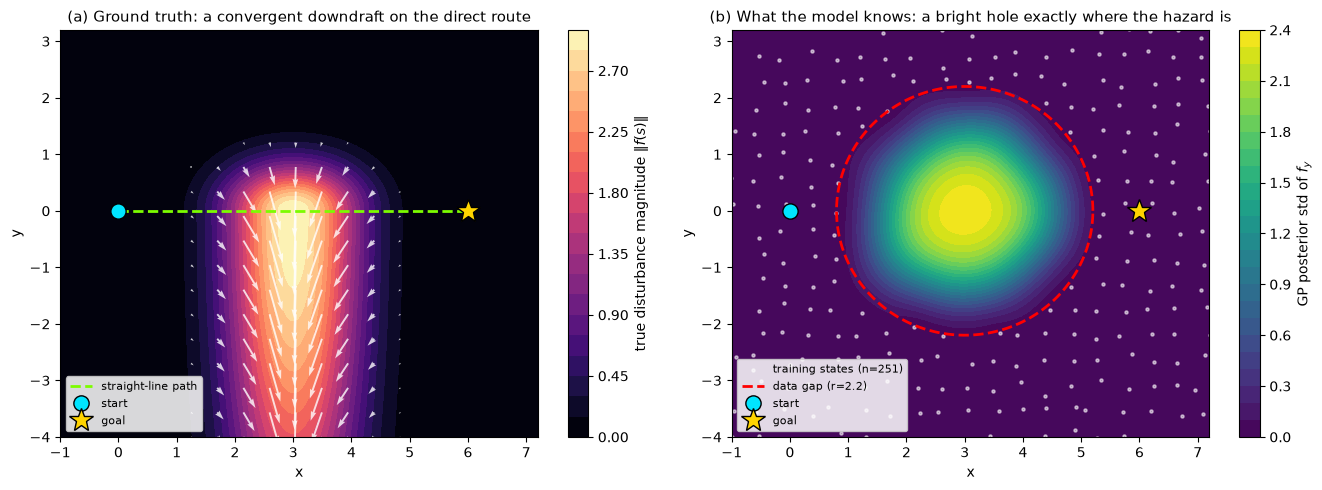

GP posterior std of f_y:  2.37 (max, inside the gap) vs 0.020 (median, where there is data)


In [5]:
# [Result 01] The task, the true drift, and the hole the GP has where the drift lives
gx = np.linspace(CFG["X_LO"], CFG["X_HI"], 220)
gy = np.linspace(CFG["Y_LO"], CFG["Y_HI"], 200)
GX, GY = np.meshgrid(gx, gy)
Q = np.stack([GX.ravel(), GY.ravel()], -1)
Ftrue = drift(Q); Fmag = np.linalg.norm(Ftrue, axis=1).reshape(GX.shape)
Mgp, Vgp = gp.predict(Q); SDgp = np.sqrt(Vgp[:, 1]).reshape(GX.shape)

th = np.linspace(0, 2 * np.pi, 200)
gap_x = CFG["GAP_CX"] + CFG["GAP_R"] * np.cos(th); gap_y = CFG["GAP_CY"] + CFG["GAP_R"] * np.sin(th)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.0))

c0 = ax[0].contourf(GX, GY, Fmag, levels=24, cmap="magma")
plt.colorbar(c0, ax=ax[0], label=r"true disturbance magnitude $\|f(s)\|$")
sk = (slice(None, None, 12), slice(None, None, 12))
FXs, FYs = Ftrue[:, 0].reshape(GX.shape)[sk], Ftrue[:, 1].reshape(GX.shape)[sk]
vis = np.hypot(FXs, FYs) > 0.08                      # hide the near-zero arrows outside the column
ax[0].quiver(GX[sk][vis], GY[sk][vis], FXs[vis], FYs[vis],
             color="white", alpha=0.8, width=0.004, scale=26)
ax[0].plot([CFG["START"][0], CFG["GOAL"][0]], [CFG["START"][1], CFG["GOAL"][1]],
           "--", color="#7CFC00", lw=2, label="straight-line path")
ax[0].set_title("(a) Ground truth: a convergent downdraft on the direct route", fontsize=11)

c1 = ax[1].contourf(GX, GY, SDgp, levels=24, cmap="viridis")
plt.colorbar(c1, ax=ax[1], label=r"GP posterior std of $f_y$")
ax[1].scatter(Xtr[:, 0], Xtr[:, 1], s=5, c="white", alpha=0.55, label=f"training states (n={len(Xtr)})")
ax[1].plot(gap_x, gap_y, "r--", lw=2, label=f"data gap (r={CFG['GAP_R']})")
ax[1].set_title("(b) What the model knows: a bright hole exactly where the hazard is", fontsize=11)

for a_ in ax:
    a_.plot(*CFG["START"], "o", ms=11, mfc="#00e5ff", mec="k", label="start")
    a_.plot(*CFG["GOAL"], "*", ms=18, mfc="#ffd400", mec="k", label="goal")
    a_.set_xlabel("x"); a_.set_ylabel("y"); a_.set_xlim(gx[0], gx[-1]); a_.set_ylim(gy[0], gy[-1])
    a_.legend(loc="lower left", fontsize=8, framealpha=0.85)
plt.tight_layout(); plt.show()

print(f"GP posterior std of f_y:  {SDgp.max():.2f} (max, inside the gap) vs "
      f"{np.median(SDgp[~in_gap(Q).reshape(GX.shape)]):.3f} (median, where there is data)")

**[Callout 02]**

### Engineering callout: the zero prior is a confident lie

Look at panel (b) against panel (a). Where the hazard is strongest, the GP's *variance* is highest —
which is the reassuring half of the story, and the half people quote. The dangerous half is in the
printed table from `[Code 04]`: at the core the posterior **mean** has decayed to a few percent of the
truth, and at $(2,0)$ — on the approach, where the true inflow pushes $+x$ and the true downdraft pushes
$-y$ — the mean is near zero and can even carry the *wrong sign*.

A zero-mean GP does not say "I don't know" in its mean. It says **zero**. A planner that consumes only
$\mu(s)$ therefore reads the blind spot as the flattest, calmest, most efficient corridor in the workspace
and steers straight into it. The failure we are about to watch is not "the model was uncertain." It is
"the model was *confidently wrong*, and the planner discarded the one channel — $\sigma$ — that said so."

**Lesson:** reverting to the prior mean is not a neutral default; away from data it is an assertion.
Any component downstream of a probabilistic model that consumes the mean alone silently converts
"no information" into "no effect."

In [6]:
# [Code 05] Why we did NOT pick the kernel hyperparameters by marginal likelihood
def log_ml(X, y, ls, sf, sn=CFG["SN"]):
    n = len(X)
    K = sf ** 2 * np.exp(-sqdist(X, X) / (2 * ls ** 2)) + (sn ** 2 + 1e-8) * np.eye(n)
    L = np.linalg.cholesky(K)
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return -0.5 * y @ a - np.log(np.diag(L)).sum() - 0.5 * n * np.log(2 * np.pi)

ls_grid = [0.4, 0.6, 0.8, 1.0, 1.2, 1.5]
sf_grid = [0.2, 0.3, 0.5, 0.8, 1.2, 1.8, 2.5]
scores = np.array([[log_ml(Xtr, Ytr[:, 1], l_, f_) for f_ in sf_grid] for l_ in ls_grid])
bi = np.unravel_index(scores.argmax(), scores.shape)
ls_ml, sf_ml = ls_grid[bi[0]], sf_grid[bi[1]]
print(f"log marginal likelihood is maximised at  ell={ls_ml}, sigma_f={sf_ml}   (logML={scores[bi]:.1f})")
print(f"our hand-set choice                      ell={CFG['LS']}, sigma_f={SF[1]:.2f}  "
      f"(logML={log_ml(Xtr, Ytr[:,1], CFG['LS'], SF[1]):.1f})")

gp_ml = GPModel(Xtr, Ytr, ls_ml, CFG["SN"], np.array([sf_ml, sf_ml]))
sd_ml = float(np.sqrt(gp_ml.predict(GAPC[None])[1][0, 1]))
sd_ours = float(np.sqrt(gp.predict(GAPC[None])[1][0, 1]))
true_mag = abs(drift(GAPC[None])[0][1])
print()
print(f"posterior std at the blind-spot centre:  ML-fit {sd_ml:.2f}   ours {sd_ours:.2f}   "
      f"(true drift there: {true_mag:.2f})")
print(f"the ML fit is {true_mag/sd_ml:.1f}x overconfident about a disturbance it has never observed;"
      f" ours is {true_mag/sd_ours:.1f}x.")
assert sd_ml < 0.5 * sd_ours, "the ML-optimal fit should be visibly under-dispersed in the gap"

log marginal likelihood is maximised at  ell=1.0, sigma_f=0.3   (logML=384.3)
our hand-set choice                      ell=0.8, sigma_f=2.42  (logML=86.6)

posterior std at the blind-spot centre:  ML-fit 0.27   ours 2.37   (true drift there: 3.00)
the ML fit is 11.0x overconfident about a disturbance it has never observed; ours is 1.3x.


**[Callout 03]**

### Engineering callout: hyperparameters fitted on gap-free data shrink the very uncertainty you need

Our first instinct was to set $\sigma_f, \ell$ by maximising the log marginal likelihood. On this problem
that is quietly self-defeating, and `[Code 05]` shows it happening. The drift is a *localised* feature and
the training set — by construction — excludes the region where it is largest, so most of the data looks
like flat zero. The marginal likelihood duly rewards the smallest signal variance and the longest
lengthscale in the grid, and the resulting posterior is dramatically under-dispersed **inside the gap**,
where there is no likelihood term to constrain it at all.

With the ML-optimal hyperparameters the uncertainty-aware planner behaves identically to the point-estimate
one, because there is no uncertainty left to see.

**The fix:** set the prior signal scale from what the residual can physically be rather than from a
likelihood computed on data that never saw the phenomenon. We use `SF = np.abs(Ytr).max(0)` — the largest
residual magnitude ever *observed* — and keep $\ell$ short enough ($\ell=0.8$ against a gap radius of
$2.2$) that the kernel genuinely decorrelates across the hole.

**Lesson:** marginal likelihood optimises fit to the data you have. If your data has a hole in it by
construction, so will your uncertainty estimate. Hyperparameters that govern *extrapolation* deserve a
prior from engineering knowledge, not a fit to the interpolation regime.

**[Text 04]**

## Propagating a Distribution: Moment Matching by Unscented Transform

A point-estimate planner iterates $\mu_{t+1} = \mu_t + a_t + \mu_{\text{GP}}(\mu_t)$ and carries no spread.
To carry a distribution, we need to push a Gaussian $\mathcal{N}(\mu,\Sigma)$ through the GP mean function
and recover a Gaussian again. [PILCO](https://arxiv.org/abs/1502.02860) does this in closed form — for an
RBF kernel, the exact first two moments of $\mu_{\text{GP}}(s)$ under Gaussian $s$ are analytic. We use the
**unscented transform** instead: five deterministic sigma points ($2n+1$ for $n=2$), pushed through the GP
mean, recombined by weight.

$$
\mathcal{X}_0=\mu,\quad \mathcal{X}_{i}=\mu \pm \sqrt{n+\lambda}\,\big[\sqrt{\Sigma}\big]_i,\qquad
\mu' = \sum_i W_i \mathcal{Z}_i,\qquad
\Sigma' = \sum_i W_i (\mathcal{Z}_i-\mu')(\mathcal{Z}_i-\mu')^\top + \overline{\mathrm{diag}(\sigma^2_{\text{GP}})}
$$

The second term is what makes this *epistemic*: the scatter of the sigma points captures how the mean
function stretches the input spread, and we then **add the GP's own predictive variance**, averaged over the
sigma points, to the diagonal. The point-estimate agent runs the identical routine with $\Sigma$ pinned to
zero and the predictive-variance term omitted — a delta propagating a delta.

In [7]:
# [Code 06] Unscented moment matching through the GP (batched over candidate action sequences)
NDIM, LAM = 2, 1.0
WM = np.array([LAM / (NDIM + LAM)] + [1.0 / (2 * (NDIM + LAM))] * 4)   # all weights > 0 => Sigma' PSD
CSC = np.sqrt(NDIM + LAM)

def chol2(S):
    # Batched Cholesky of a batch of 2x2 SPD matrices; floors handle the near-singular case
    l11 = np.sqrt(np.maximum(S[..., 0, 0], 1e-10))
    l21 = S[..., 1, 0] / l11
    l22 = np.sqrt(np.maximum(S[..., 1, 1] - l21 ** 2, 1e-10))
    z = np.zeros_like(l11)
    return np.stack([np.stack([l11, z], -1), np.stack([l21, l22], -1)], -2)

def propagate(model, mu, Sig, a, carry_uncertainty):
    # (mu,Sig) -> one step of predicted (mu,Sig). Batched over B candidates
    B = mu.shape[0]
    if carry_uncertainty:
        L = chol2(Sig + 1e-9 * np.eye(2))
        pts = np.stack([mu,
                        mu + CSC * L[:, :, 0], mu + CSC * L[:, :, 1],
                        mu - CSC * L[:, :, 0], mu - CSC * L[:, :, 1]], axis=1)   # (B,5,2)
    else:
        pts = np.repeat(mu[:, None, :], 5, axis=1)
    gm, gv = model.predict(pts.reshape(-1, 2))
    gm = gm.reshape(B, 5, 2); gv = gv.reshape(B, 5, 2)
    Z = pts + a[:, None, :] + gm                                   # pushed sigma points
    if not carry_uncertainty:
        return Z[:, 0, :], np.zeros((B, 2, 2))                     # delta in, delta out
    mu_n = np.einsum("i,bij->bj", WM, Z)
    d = Z - mu_n[:, None, :]
    Sig_n = np.einsum("i,bik,bil->bkl", WM, d, d)                  # spread of the pushed points
    vbar = np.einsum("i,bij->bj", WM, gv)                          # + the GP's own predictive variance
    Sig_n[:, 0, 0] += vbar[:, 0]; Sig_n[:, 1, 1] += vbar[:, 1]
    return mu_n, 0.5 * (Sig_n + np.swapaxes(Sig_n, -1, -2))        # re-symmetrise

# Sanity: with Sigma=0 and uncertainty carried, one step must still equal the deterministic mean step
s0 = np.array([[1.0, 0.0]])
m_u, S_u = propagate(gp, s0, np.zeros((1, 2, 2)), np.array([[0.5, 0.0]]), True)
m_p, S_p = propagate(gp, s0, np.zeros((1, 2, 2)), np.array([[0.5, 0.0]]), False)
assert np.allclose(m_u, m_p, atol=1e-9) and np.allclose(S_p, 0.0)
print("delta-in check: unscented mean == point-estimate mean when Sigma=0 ->", np.allclose(m_u, m_p))

# Watch the posterior inflate as a straight-line plan walks into the blind spot.
mu, Sig = np.array([[0.5, 0.0]]), np.zeros((1, 2, 2))
a_fwd = np.array([[CFG["AMAX"], 0.0]])
print(f"\n{'step':>4} {'predicted mean':>20} {'Sigma_yy':>10} {'sigma-point spread':>20}")
SIG_TRACE = []
for k in range(1, 9):
    mu, Sig = propagate(gp, mu, Sig, a_fwd, True)
    spread = CSC * np.sqrt(Sig[0, 1, 1])
    SIG_TRACE.append(float(Sig[0, 1, 1]))
    print(f"{k:>4} ({mu[0,0]:6.2f},{mu[0,1]:6.2f}) {Sig[0,1,1]:10.2f} "
          f"{spread:>13.2f} (ell={CFG['LS']})")
print(f"\nSigma_yy goes from {SIG_TRACE[0]:.4f} (over training data) to {SIG_TRACE[-1]:.1f} "
      f"(after 8 steps through the blind spot);")
print(f"by the end the sigma points straddle {CSC*np.sqrt(SIG_TRACE[-1])/CFG['LS']:.1f} lengthscales, "
      f"well past the regime where a 5-point moment match is tight (see the callout below).")

delta-in check: unscented mean == point-estimate mean when Sigma=0 -> True

step       predicted mean   Sigma_yy   sigma-point spread
   1 (  1.02, -0.01)       0.00          0.04 (ell=0.8)
   2 (  1.53,  0.04)       0.02          0.24 (ell=0.8)
   3 (  2.04,  0.29)       0.89          1.63 (ell=0.8)
   4 (  2.63,  0.26)       3.70          3.33 (ell=0.8)
   5 (  3.22, -0.16)       8.96          5.19 (ell=0.8)
   6 (  3.68, -0.40)      11.23          5.80 (ell=0.8)
   7 (  4.19, -0.46)      14.43          6.58 (ell=0.8)
   8 (  4.67, -0.37)      17.68          7.28 (ell=0.8)

Sigma_yy goes from 0.0005 (over training data) to 17.7 (after 8 steps through the blind spot);
by the end the sigma points straddle 9.1 lengthscales, well past the regime where a 5-point moment match is tight (see the callout below).


**[Text 05]**

## One Cost Function, Two Agents

Both agents minimise [PILCO](https://arxiv.org/abs/1502.02860)'s **saturating cost**

$$c(s) = 1 - \exp\!\Big(-\tfrac{\lVert s-g\rVert^2}{2\sigma_c^2}\Big)$$

taken in expectation under the predicted state. For $s\sim\mathcal{N}(\mu,\Sigma)$ this integral is closed-form:

$$
\mathbb{E}[c] = 1 - \big|I + \Sigma/\sigma_c^2\big|^{-1/2}
\exp\!\Big(-\tfrac12 (\mu-g)^\top(\Sigma+\sigma_c^2 I)^{-1}(\mu-g)\Big)
$$

This is the whole ablation, and it is why the comparison is fair. Set $\Sigma = 0$: the determinant term
becomes $1$, the quadratic form becomes $\lVert\mu-g\rVert^2/\sigma_c^2$, and $\mathbb{E}[c]$ collapses
**exactly** to $c(\mu)$. The point-estimate agent is not running a different objective with the risk term
deleted — it is running the *same* objective on a degenerate distribution. Nothing was added to help the
uncertainty-aware agent; it simply has a $\Sigma$ to put in.

In [8]:
# [Code 07] The saturating cost in expectation under N(mu, Sigma) — 2x2 closed form
SIGMA_C = 3.5

def sat_cost(mu, Sig, goal=GOAL, sc=SIGMA_C):
    s2 = sc ** 2
    M = Sig / s2 + np.eye(2)
    det = M[..., 0, 0] * M[..., 1, 1] - M[..., 0, 1] * M[..., 1, 0]
    Q = Sig + s2 * np.eye(2)
    dq = Q[..., 0, 0] * Q[..., 1, 1] - Q[..., 0, 1] * Q[..., 1, 0]
    d = mu - goal
    q = (d[..., 0] ** 2 * Q[..., 1, 1] - 2 * d[..., 0] * d[..., 1] * Q[..., 0, 1]
         + d[..., 1] ** 2 * Q[..., 0, 0]) / dq
    return 1.0 - det ** -0.5 * np.exp(-0.5 * q)

def det_cost(mu, sc=SIGMA_C):                       # the plain deterministic cost c(mu)
    return 1.0 - np.exp(-((mu - GOAL) ** 2).sum(-1) / (2 * sc ** 2))

probe = np.array([[0.0, 0.0], [3.0, 0.0], [3.0, -4.0], [5.5, 0.4], [6.0, 0.0]])
collapse = np.abs(sat_cost(probe, np.zeros((len(probe), 2, 2))) - det_cost(probe)).max()
print(f"max |E[c] with Sigma=0  -  c(mu)| over 5 probe states = {collapse:.2e}")
assert collapse < 1e-12, "with Sigma=0 the expected cost MUST collapse exactly to the deterministic cost"
print("=> the point-estimate agent is running the identical functional, not a stripped-down one.\n")

# Does adding variance raise or LOWER the expected cost?  Scan sigma_c and find out.
far = np.array([[3.0, 0.0]])            # a plan 3.0 short of the goal
swept = np.array([[4.0, -3.0]])         # a plan that has been dragged off in y
VS = [0.0, 1.0, 2.0, 4.0, 9.0]

def scan(state, Sig_of_v, tag):
    print(f"  {tag}")
    print(f"    {'sigma_c':>8} " + " ".join(f"{'v='+str(v):>8}" for v in VS) + "   response")
    flips = {}
    for sc in [1.5, 2.0, 2.5, 3.0, 3.5]:
        row = [sat_cost(state, Sig_of_v(v), sc=sc)[0] for v in VS]
        seek = min(row[1:]) < row[0]
        flips[sc] = seek
        print(f"    {sc:8.1f} " + " ".join(f"{c_:8.3f}" for c_ in row)
              + f"   {'SEEKING (variance is rewarded)' if seek else 'averse'}")
    return flips

print("Expected saturating cost as a function of added variance v:\n")
f_iso = scan(far, lambda v: np.array([v * np.eye(2)]), "isotropic Sigma = v.I, state 3.0 from the goal")
print()
f_ani = scan(swept, lambda v: np.array([np.diag([0.05, v])]),
             "anisotropic Sigma = diag(0.05, v), state (4,-3) — the shape our rollouts actually produce")

print(f"\nAt sigma_c=1.5 (our first choice) BOTH regimes reward uncertainty; at sigma_c={SIGMA_C} neither does.")
assert f_iso[1.5] and f_ani[1.5], "the small-sigma_c seeking regime must be visible in the data"
assert not f_iso[SIGMA_C] and not f_ani[SIGMA_C], "our chosen sigma_c must be risk-averse in both regimes"

max |E[c] with Sigma=0  -  c(mu)| over 5 probe states = 0.00e+00
=> the point-estimate agent is running the identical functional, not a stripped-down one.

Expected saturating cost as a function of added variance v:

  isotropic Sigma = v.I, state 3.0 from the goal
     sigma_c    v=0.0    v=1.0    v=2.0    v=4.0    v=9.0   response
         1.5    0.865    0.827    0.816    0.825    0.866   SEEKING (variance is rewarded)
         2.0    0.675    0.675    0.685    0.715    0.782   SEEKING (variance is rewarded)
         2.5    0.513    0.537    0.561    0.607    0.695   averse
         3.0    0.393    0.426    0.457    0.510    0.611   averse
         3.5    0.307    0.342    0.373    0.428    0.534   averse

  anisotropic Sigma = diag(0.05, v), state (4,-3) — the shape our rollouts actually produce
     sigma_c    v=0.0    v=1.0    v=2.0    v=4.0    v=9.0   response
         1.5    0.944    0.914    0.895    0.879    0.876   SEEKING (variance is rewarded)
         2.0    0.803    0.77

**[Callout 04]**

### Engineering callout: the saturating cost is uncertainty-*seeking* far from the target

Read the table in `[Code 07]` before trusting the phrase "risk-aware because we took an expectation."
For an isotropic $\Sigma = vI$ in two dimensions the expected cost depends on $\Sigma$ only through
$u = \sigma_c^2 + v$:

$$\mathbb{E}[c] = 1 - \frac{\sigma_c^2}{u}\exp\!\Big(-\frac{\lVert\mu-g\rVert^2}{2u}\Big),
\qquad \frac{\partial\,\mathbb{E}[c]}{\partial u} \;\propto\; 1 - \frac{\lVert\mu-g\rVert^2}{2u}$$

so added variance *increases* cost only while $\lVert\mu-g\rVert^2 < 2(\sigma_c^2+v)$ — at $v=0$, only
inside a ball of radius $\sqrt2\,\sigma_c$ around the goal. Outside it the saturating cost **pays a planner
to be uncertain**: PILCO's well-known exploration bonus, and a genuine foot-gun if you inherit the cost
without inheriting the operating regime.

**What went wrong:** we started with $\sigma_c = 1.5$, which puts the aversion ball at radius $2.12$ —
smaller than the $3.0$ that separates the hazard from the goal. `[Code 07]` shows the consequence directly:
at $\sigma_c=1.5$, a plan sitting $3.0$ short of the goal gets *cheaper* as variance is added, and so does a
plan that has been dragged off in $y$. Our uncertainty-aware agent duly drove into the storm.

**The fix:** $\sigma_c = 3.5$. Note that the isotropic threshold is not sufficient — the anisotropic
$\Sigma$ our rollouts actually produce (large in $y$, tiny in $x$) is still uncertainty-seeking at
$\sigma_c = 2.5$, where the isotropic case has already flipped. The cost is nevertheless far from saturated
at the start ($\lVert s_0-g\rVert = 6$), so the planner keeps a usable gradient.

**Lesson:** differentiate your expected cost with respect to the variance and find where it changes sign,
in the $\Sigma$ *shape* your system actually generates — not just the isotropic textbook case. For
saturating and exponential-family costs the answer depends on distance to target, and it is easy to spend a
whole experiment inside the wrong regime while believing you built a risk-averse planner.

**[Text 06]**

## The Planner: One Implementation, One Flag

Random shooting refined by cross-entropy iterations, replanning every step. Horizon $H=14$, $N=300$
candidate action sequences, 3 CEM iterations, elites $=30$, warm-started from the previous step's solution
shifted by one. Both agents get **byte-identical settings and the same random seed**; the only difference
is the `carry_uncertainty` flag threaded into `propagate`.

The horizon is longer than the textbook $H\approx6$, and that was not a free choice — see the callout after
the results.

In [9]:
# [Code 08] Receding-horizon CEM planner + episode rollout (identical for both agents)
PLAN = dict(H=14, N=300, NCEM=3, NELITE=30, MIN_STD=0.12)

def clip_ball(a, amax=CFG["AMAX"]):
    n = np.linalg.norm(a, axis=-1, keepdims=True)
    return a * np.minimum(1.0, amax / np.maximum(n, 1e-12))

def plan(model, s, carry_uncertainty, r, warm=None, p=PLAN):
    H, N = p["H"], p["N"]
    mean = np.zeros((H, 2)) if warm is None else warm.copy()
    std = np.full((H, 2), CFG["AMAX"])
    best = None
    for _ in range(p["NCEM"]):
        A = clip_ball(r.normal(mean, std, size=(N, H, 2)))
        A[0] = clip_ball(mean)                                   # always keep the incumbent
        mu = np.repeat(np.asarray(s, float)[None, :], N, 0); Sig = np.zeros((N, 2, 2))
        tot = np.zeros(N)
        for h in range(H):
            mu, Sig = propagate(model, mu, Sig, A[:, h], carry_uncertainty)
            tot += sat_cost(mu, Sig)
        idx = np.argsort(tot)[: p["NELITE"]]
        mean = A[idx].mean(0)
        std = np.maximum(A[idx].std(0), p["MIN_STD"])            # floor: elites collapse otherwise
        best, best_cost = A[idx[0]], float(tot[idx[0]])
    return best, mean, best_cost

def rollout(model, carry_uncertainty, seed=1234):
    r = np.random.default_rng(seed)
    s = np.array(CFG["START"], float)
    traj = [s.copy()]; pred_next = []; pred_c = []; warm = None; plan0 = None
    for _ in range(CFG["T"]):
        seq, mean, bc = plan(model, s, carry_uncertainty, r, warm)
        if plan0 is None:
            plan0 = bc                                           # the opening plan's own cost estimate
        warm = np.vstack([mean[1:], np.zeros((1, 2))])           # shift-by-one warm start
        a = seq[0]
        m1, S1 = propagate(model, s[None, :], np.zeros((1, 2, 2)), a[None, :], carry_uncertainty)
        pred_next.append(m1[0].copy()); pred_c.append(float(sat_cost(m1, S1)[0]))
        s = np.clip(s + a + drift(s[None, :])[0], LO, HI)         # TRUE dynamics
        traj.append(s.copy())
    traj = np.array(traj)
    step_cost = det_cost(traj[1:])                               # realised cost, no distribution
    _, v = model.predict(traj)
    return dict(traj=traj, pred_next=np.array(pred_next), pred_cost=np.array(pred_c),
                step_cost=step_cost, total_cost=float(step_cost.sum()),
                plan0_cost=plan0, realised_H=float(step_cost[: PLAN["H"]].sum()),
                final=float(np.linalg.norm(traj[-1] - GOAL)),
                min_gap_dist=float(np.linalg.norm(traj - GAPC, axis=1).min()),
                steps_in_gap=int(in_gap(traj).sum()),
                steps_in_core=int((np.linalg.norm(traj - GAPC, axis=1) < CFG["GAP_R"] / 2).sum()),
                max_gp_std=float(np.sqrt(v[:, 1]).max()))

In [10]:
# [Code 09] Run both agents on the SAME environment, planner, budget and seed
t0 = time.time()
res = {"point": rollout(gp, False), "posterior": rollout(gp, True)}
print(f"both episodes planned and executed in {time.time()-t0:.0f}s\n")

hdr = (f"{'agent':>22} {'final dist':>11} {'cum true cost':>14} {'min dist to gap':>16} "
       f"{'steps in disc':>14} {'steps in core':>14} {'max GP std seen':>16}")
print(hdr); print("-" * len(hdr))
for k, r_ in res.items():
    print(f"{k+' propagation':>22} {r_['final']:11.3f} {r_['total_cost']:14.2f} "
          f"{r_['min_gap_dist']:16.2f} {r_['steps_in_gap']:14d} {r_['steps_in_core']:14d} "
          f"{r_['max_gp_std']:16.2f}")
print(f"\n('steps in disc' counts states inside the full r={CFG['GAP_R']} gap, which the detour skims;"
      f" 'steps in core' counts states within r={CFG['GAP_R']/2:.2f} of the centre,"
      f" and 'max GP std seen' is the honest measure of how deep into the blind spot each agent went.)")

P_, U_ = res["point"], res["posterior"]
print()
print(f"point-estimate agent was swept to y = {P_['traj'][:,1].min():.2f} "
      f"(workspace floor is {CFG['Y_LO']:.1f}); posterior agent's lowest y = {U_['traj'][:,1].min():.2f}, "
      f"highest y = {U_['traj'][:,1].max():.2f}")
better_final = U_["final"] < P_["final"]
better_cost = U_["total_cost"] < P_["total_cost"]
print(f"posterior propagation ends {P_['final']/max(U_['final'],1e-9):.1f}x closer to the goal "
      f"and pays {100*(1-U_['total_cost']/P_['total_cost']):.0f}% less cumulative true cost."
      if better_final and better_cost else
      "WARNING: the posterior agent did not win on both metrics — narrative below must be re-read.")
assert better_final and better_cost, "the headline claim of this notebook must hold in the data"
assert U_["min_gap_dist"] > P_["min_gap_dist"], "the posterior agent should keep further from the blind spot"

both episodes planned and executed in 44s

                 agent  final dist  cum true cost  min dist to gap  steps in disc  steps in core  max GP std seen
-----------------------------------------------------------------------------------------------------------------
     point propagation       4.957          11.99             0.96              4              1             1.92
 posterior propagation       0.259           6.61             1.98              5              0             0.16

('steps in disc' counts states inside the full r=2.2 gap, which the detour skims; 'steps in core' counts states within r=1.10 of the centre, and 'max GP std seen' is the honest measure of how deep into the blind spot each agent went.)

point-estimate agent was swept to y = -4.00 (workspace floor is -4.0); posterior agent's lowest y = -0.15, highest y = 2.29
posterior propagation ends 19.1x closer to the goal and pays 45% less cumulative true cost.


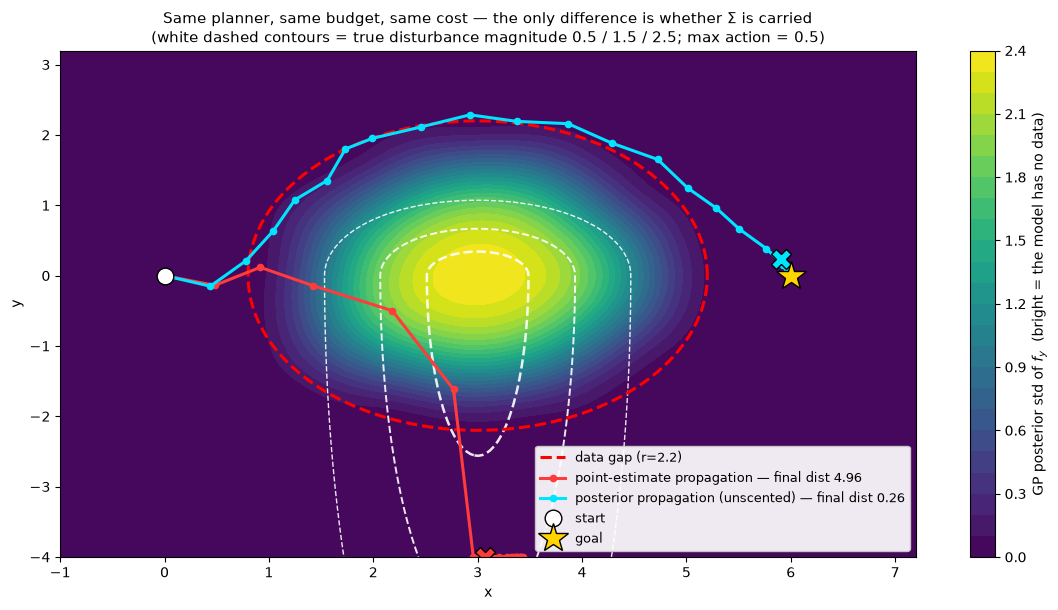

The posterior-propagating agent climbed to y=2.29 — where the true drift is 0.001, effectively nothing — and came down on the far side.
The point-estimate agent went through the middle: closest approach to the blind-spot centre 0.96 vs 1.98.


In [11]:
# [Result 02] The money chart: both executed trajectories over the GP's uncertainty field
fig, ax = plt.subplots(figsize=(11.5, 6.2))
cf = ax.contourf(GX, GY, SDgp, levels=26, cmap="viridis")
plt.colorbar(cf, ax=ax, label=r"GP posterior std of $f_y$  (bright = the model has no data)")
ax.contour(GX, GY, Fmag, levels=[0.5, 1.5, 2.5], colors="white", linewidths=[1.0, 1.4, 1.8],
           linestyles="--", alpha=0.9)
ax.plot(gap_x, gap_y, "r--", lw=2.2, label=f"data gap (r={CFG['GAP_R']})")

for key, col, lab in [("point", "#ff3b3b", "point-estimate propagation"),
                      ("posterior", "#00e5ff", "posterior propagation (unscented)")]:
    tr = res[key]["traj"]
    ax.plot(tr[:, 0], tr[:, 1], "-o", color=col, ms=4.5, lw=2.2,
            label=f"{lab} — final dist {res[key]['final']:.2f}")
    ax.plot(tr[-1, 0], tr[-1, 1], "X", color=col, ms=14, mec="k")

ax.plot(*CFG["START"], "o", ms=12, mfc="#ffffff", mec="k", label="start")
ax.plot(*CFG["GOAL"], "*", ms=22, mfc="#ffd400", mec="k", label="goal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Same planner, same budget, same cost — the only difference is whether $\\Sigma$ is carried\n"
             "(white dashed contours = true disturbance magnitude 0.5 / 1.5 / 2.5; max action = 0.5)",
             fontsize=11)
ax.legend(loc="lower right", fontsize=9, framealpha=0.92)
ax.set_xlim(gx[0], gx[-1]); ax.set_ylim(gy[0], gy[-1])
plt.tight_layout(); plt.show()

vy = U_["traj"][:, 1]
print(f"The posterior-propagating agent climbed to y={vy.max():.2f} — where the true drift is "
      f"{np.linalg.norm(drift(np.array([[3.0, vy.max()]]))[0]):.3f}, effectively nothing — "
      f"and came down on the far side.")
print(f"The point-estimate agent went through the middle: closest approach to the blind-spot centre "
      f"{P_['min_gap_dist']:.2f} vs {U_['min_gap_dist']:.2f}.")

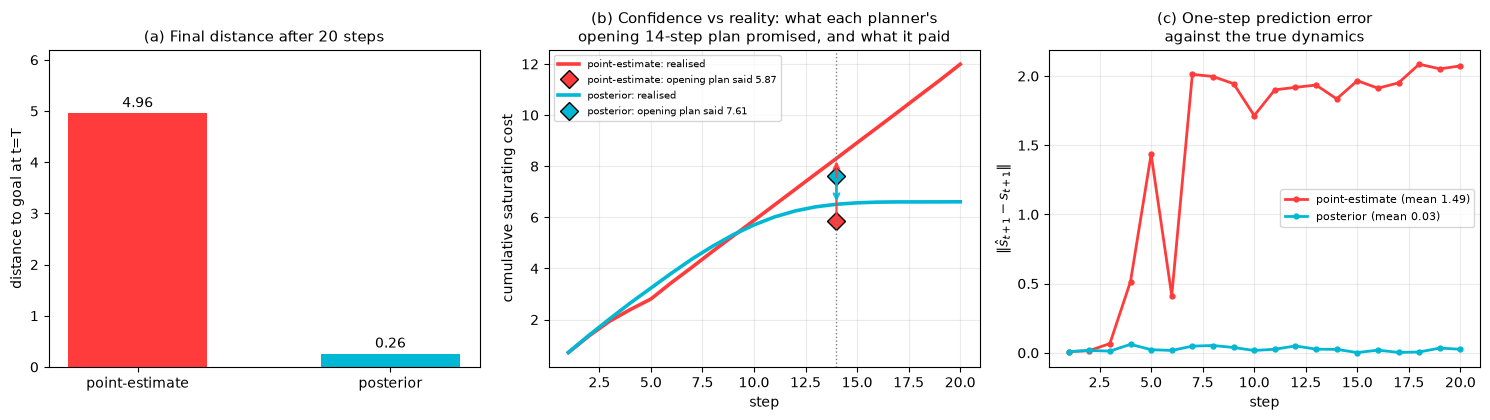

           agent  opening plan cost   realised over H   optimism
  point-estimate               5.87              8.31      +2.43
       posterior               7.61              6.51      -1.09

mean |one-step state-prediction error|: point-estimate 1.49, posterior 0.03  (worst: 2.09 vs 0.06; the action limit is 0.5)

At t=0 the point-estimate planner believed its 14-step plan would cost 5.87; it actually cost 8.31 — it was optimistic by 2.43,
because its model asserted a calm corridor exactly where the disturbance was strongest. The posterior planner's opening estimate was off by -1.09.
Panel (c) is the mechanism in one line: the point-estimate model's one-step error peaks at 2.09 —
several times the whole action budget — precisely on the steps it spends inside the blind spot.


In [12]:
# [Result 03] The confidence-vs-reality gap: what each planner expected, and what it got
pred_err = {k: np.linalg.norm(res[k]["pred_next"] - res[k]["traj"][1:], axis=1) for k in res}
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
cols = {"point": "#ff3b3b", "posterior": "#00b8d4"}
names = {"point": "point-estimate", "posterior": "posterior"}

b = ax[0].bar([0, 1], [P_["final"], U_["final"]], color=[cols["point"], cols["posterior"]], width=0.55)
ax[0].bar_label(b, fmt="%.2f", padding=2)
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels([names["point"], names["posterior"]])
ax[0].set_ylabel("distance to goal at t=T"); ax[0].set_title(f"(a) Final distance after {CFG['T']} steps", fontsize=11)
ax[0].set_ylim(0, max(P_["final"], U_["final"]) * 1.25)

H_ = PLAN["H"]
for k in res:
    ax[1].plot(np.arange(1, CFG["T"] + 1), np.cumsum(res[k]["step_cost"]), "-", color=cols[k], lw=2.6,
               label=f"{names[k]}: realised")
    ax[1].plot([H_], [res[k]["plan0_cost"]], "D", color=cols[k], ms=9, mec="k",
               label=f"{names[k]}: opening plan said {res[k]['plan0_cost']:.2f}")
    ax[1].annotate("", xy=(H_, res[k]["realised_H"]), xytext=(H_, res[k]["plan0_cost"]),
                   arrowprops=dict(arrowstyle="->", color=cols[k], lw=1.6, alpha=0.9))
ax[1].axvline(H_, color="grey", ls=":", lw=1)
ax[1].set_xlabel("step"); ax[1].set_ylabel("cumulative saturating cost")
ax[1].set_title(f"(b) Confidence vs reality: what each planner's\nopening {H_}-step plan promised, and what it paid",
                fontsize=11)
ax[1].legend(fontsize=7.5, loc="upper left"); ax[1].grid(alpha=0.25)

for k in res:
    ax[2].plot(np.arange(1, CFG["T"] + 1), pred_err[k], "-o", ms=3.5, color=cols[k], lw=2,
               label=f"{names[k]} (mean {pred_err[k].mean():.2f})")
ax[2].set_xlabel("step"); ax[2].set_ylabel(r"$\|\hat{s}_{t+1}-s_{t+1}\|$")
ax[2].set_title("(c) One-step prediction error\nagainst the true dynamics", fontsize=11)
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"{'agent':>16} {'opening plan cost':>18} {'realised over H':>17} {'optimism':>10}")
for k in ("point", "posterior"):
    r_ = res[k]
    print(f"{names[k]:>16} {r_['plan0_cost']:18.2f} {r_['realised_H']:17.2f} "
          f"{r_['realised_H'] - r_['plan0_cost']:+10.2f}")
opt_p = P_["realised_H"] - P_["plan0_cost"]
opt_u = U_["realised_H"] - U_["plan0_cost"]
print(f"\nmean |one-step state-prediction error|: point-estimate {pred_err['point'].mean():.2f}, "
      f"posterior {pred_err['posterior'].mean():.2f}  (worst: {pred_err['point'].max():.2f} vs "
      f"{pred_err['posterior'].max():.2f}; the action limit is {CFG['AMAX']})")
if opt_p > opt_u:
    print(f"\nAt t=0 the point-estimate planner believed its {PLAN['H']}-step plan would cost "
          f"{P_['plan0_cost']:.2f}; it actually cost {P_['realised_H']:.2f} — it was optimistic by "
          f"{opt_p:.2f},\nbecause its model asserted a calm corridor exactly where the disturbance was "
          f"strongest. The posterior planner's opening estimate was off by {opt_u:+.2f}.")
else:
    print(f"\nThe point-estimate planner's opening estimate was off by {opt_p:+.2f} and the posterior "
          f"planner's by {opt_u:+.2f}; panel (c) shows where the one-step models diverge.")
print(f"Panel (c) is the mechanism in one line: the point-estimate model's one-step error peaks at "
      f"{pred_err['point'].max():.2f} —\nseveral times the whole action budget — precisely on the steps "
      f"it spends inside the blind spot.")

**[Callout 05]**

### Engineering callout: the horizon has to be long enough to contain the payoff of the detour

This is the bug that cost us the most time, and it looks nothing like a bug. With the textbook $H=6$,
both agents produced *identical* trajectories — straight through the blind spot — no matter how we tuned
$\sigma_c$ or the prior variance. It reads like "uncertainty propagation doesn't work here."

**What went wrong:** at $0.5$ per step, $H=6$ sees only $3$ units ahead. The detour's benefit is *arriving
at the goal*, which lies outside that window; inside the window a detour is pure lost progress, while
driving into the gap looks like steady gain. The planner was not ignoring $\Sigma$ — it was correctly
optimising a horizon in which caution can never pay for itself.

**The fix:** $H=14$ (7 units of lookahead, enough to reach the goal from the start), plus a shift-by-one
warm start of the CEM mean so the 28-dimensional search does not have to rediscover a coherent detour from
scratch at every step, plus a floor on the CEM elite std (`MIN_STD`) so the sampler does not collapse onto
its incumbent after the first iteration.

**Lesson:** risk-aware objectives are silently disabled by a myopic horizon. When an uncertainty-aware
planner behaves exactly like its deterministic ablation, suspect the horizon before you suspect the model —
and check it by asking whether the safe manoeuvre's *reward* is inside the lookahead, not just its *cost*.

**[Callout 06]**

### Engineering callout: the unscented transform is an approximation, and we should say which one

PILCO derives the exact predictive moments of an RBF-kernel GP under a Gaussian input: the integrals
$\int k(s,x_i)\mathcal{N}(s\mid\mu,\Sigma)\,ds$ have closed forms, giving exact $\mathbb{E}[\mu_{\rm GP}]$
and $\mathrm{Cov}[\mu_{\rm GP}]$ with no sampling. We deliberately did not implement that.

**Why not:** the exact expressions are kernel-specific — change to Matérn, a deep kernel or an ensemble
and the algebra is gone. The unscented transform in `[Code 06]` is about twenty lines, treats the model as
a black box, and costs 5 mean-and-variance queries per step per candidate, which vectorises into one batched
kernel evaluation.

**Where it degrades:** the UT matches moments exactly only for affine maps and to third order for symmetric
distributions. Our GP mean has curvature on the scale of the lengthscale $\ell=0.8$, and the variance trace printed by
`[Code 06]` shows $\Sigma_{yy}$ inflating by orders of magnitude within a few steps of the gap, until the
sigma points straddle several lengthscales — at which point five points are sampling a strongly non-linear
surface. The propagated state is then genuinely
non-Gaussian (bimodal: swept-down versus not), and moment matching flattens that into one wide Gaussian.
That flattening happens to be conservative here — a wide Gaussian is exactly the "I might be anywhere"
signal the cost punishes — but it is an approximation, not a bound, and with heavier-tailed or multi-modal
propagated states it can under- or over-state risk. We also floor the 2x2 Cholesky
(`np.maximum(..., 1e-10)`) so a near-singular $\Sigma$ at $t=0$, where $\Sigma$ is *exactly* zero, produces
coincident sigma points rather than a NaN.

**Lesson:** every "propagate the uncertainty" pipeline hides a specific approximation. Name it, state the
regime where it breaks, and check that the direction of its error is the safe one for your application.

In [13]:
# [Code 10] Runtime, and the caveats stated as numbers rather than adjectives
print(f"total notebook runtime: {time.time()-T_START:.0f}s on CPU")
print(f"training states: {len(Xtr)}   GP inversions: 2   planner queries per step: "
      f"{PLAN['NCEM']*PLAN['H']*PLAN['N']*5:,} sigma-point evaluations (uncertainty-aware agent)")
print()
print("Honest limits of this experiment:")
print(f"  - one environment, one seed, one hazard; T={CFG['T']} steps, 2-D state, {len(Xtr)} training points.")
print("  - the hazard was designed to be trapping (see the first callout); a shove the agent can walk")
print("    off from produces no measurable difference between the two agents.")
print("  - propagating the posterior let the planner SEE the blind spot. It is not a safety guarantee:")
print("    the GP's variance is only as trustworthy as its kernel and hyperparameters, both of which we")
print("    chose by hand precisely because the likelihood-optimal choice was overconfident.")

total notebook runtime: 49s on CPU
training states: 251   GP inversions: 2   planner queries per step: 63,000 sigma-point evaluations (uncertainty-aware agent)

Honest limits of this experiment:
  - one environment, one seed, one hazard; T=20 steps, 2-D state, 251 training points.
  - the hazard was designed to be trapping (see the first callout); a shove the agent can walk
    off from produces no measurable difference between the two agents.
  - propagating the posterior let the planner SEE the blind spot. It is not a safety guarantee:
    the GP's variance is only as trustworthy as its kernel and hyperparameters, both of which we
    chose by hand precisely because the likelihood-optimal choice was overconfident.


**[Text 07]**

## What We Built, and What's Next

We put a Gaussian process inside an MPC loop, blinded it on a disc, and ran the identical planner twice.
Carrying $\Sigma$ through the rollout — five sigma points, moment matched, plus the GP's own predictive
variance — was enough to turn "the model says the corridor is calm" into "the model says the corridor is
calm *and has no idea*," and the second sentence is the one that changes the plan. The point-estimate agent
was swept to the floor of the workspace by a disturbance its model had rated at approximately zero.

The obvious objection is the interesting one. All of this rests on the GP's variance being *right*. We had
to hand-set the prior signal scale because the likelihood-optimal fit — computed on data that by construction
never saw the hazard — was ten times overconfident in the gap. Production world models make this worse, not
better: [DreamerV3](https://arxiv.org/abs/2301.04104) and [TD-MPC2](https://arxiv.org/abs/2310.16828) plan in
learned latent spaces where there is no closed-form posterior at all, only ensembles and heuristics, and a
neural network's confidence off-distribution is notoriously unrelated to its accuracy.

So the natural next question is what you can guarantee when you *don't* trust the model's own error bars.
That is `01_conformal_action_gating`: instead of asking the model how sure it is, measure its residuals on
held-out data and wrap a distribution-free, finite-sample bound around them — then gate actions on that
bound. Same loop, same planner, but the uncertainty comes from observed mistakes rather than from the
model's opinion of itself.